# QAOA for Two Electrons in a Double Quantum Well

**This Notebook is Based on:** *Two-Qubit Implementation of QAOA for MAX-CUT on an NV-Center Quantum Processor*, arXiv:2604.00949 by  
Leon E. Röscher et al.


---

This notebook retains the theoretical framework of Sections 1 and 2 of the original manuscript
and replaces the NV-center hardware implementation with a new physical realisation:
**two spin-½ electrons confined in a double quantum well**, one electron per well.
Each electron's spin degree of freedom encodes a qubit, and the spin–spin exchange interaction
between the two wells provides the entangling operation required by QAOA.
A pure-NumPy statevector simulation then realises the full QAOA pipeline on this system.

**Contents**

| Section | Topic |
|:--------|:------|
| 1 | Introduction — NISQ devices, variational algorithms, and QAOA |
| 2 | QAOA formulation of MAX-CUT |
| 3 | Two electrons in a double quantum well as a two-qubit system |
| 4 | Python simulation of QAOA on the double-well system |


## Section 1 — Introduction

Noisy Intermediate-Scale Quantum (NISQ) devices are quantum processors with limited qubit
numbers and non-negligible noise, for which deep fault-tolerant circuits remain out of reach
[Preskill 2018]. Within this regime, **variational quantum algorithms** have emerged as a
promising approach because they combine shallow parameterised quantum circuits with classical
optimisation. Among these, the **Quantum Approximate Optimisation Algorithm (QAOA)**, introduced
by Farhi et al. [Farhi 2014], is one of the most widely studied methods for combinatorial
optimisation on near-term hardware.

In this work we focus on **MAX-CUT**, a standard NP-hard combinatorial problem that serves as a
natural benchmark for QAOA. Its graph-based structure makes it particularly suitable for studying
the relationship between a problem Hamiltonian and the connectivity of a quantum processing unit.

A central requirement for realising QAOA is the ability to implement a two-qubit entangling
gate — specifically the $RZZ$ gate — between any pair of qubits encoding connected graph vertices.
In this notebook, rather than mapping the two-qubit register to the electron spin and nuclear
spin of an NV$^-$ centre, we use **two spin-$\frac{1}{2}$ electrons trapped in separate
potential wells**. Each electron's spin state $\{|\!\uparrow\rangle, |\!\downarrow\rangle\}$
encodes a qubit, and the exchange interaction between the two wells provides the native entangling
operation. This realisation is directly relevant to semiconductor spin-qubit platforms such as
GaAs or Si/SiGe double quantum dots, where spin-exchange coupling between neighbouring dots is a
standard two-qubit gate mechanism.

The double-well system is analysed at the level of **spin degrees of freedom only**: orbital and
charge dynamics are assumed frozen, leaving a clean two-qubit Hilbert space
$\mathcal{H} = \mathbb{C}^2 \otimes \mathbb{C}^2$.


## Section 2 — QAOA Formulation of MAX-CUT

### 2.1  Classical cost function

The quantum approximate optimisation algorithm was introduced as a hybrid quantum–classical
algorithm for approximately solving combinatorial optimisation problems [Farhi 2014]. Candidate
solutions are encoded as bit strings $x \in \{0,1\}^n$, representing a graph partition or
two-colouring. In the **minimisation formulation** natural to the Hamiltonian language, we define

$$
x^* = \arg\min_{x \in \{0,1\}^n} C(x).
$$

For a finite simple undirected graph $G = (V, E)$ with adjacency matrix $A$ (where
$A_{ij} = A_{ji}$ and $A_{ii} = 0$), MAX-CUT seeks a partition of $V$ into two disjoint subsets
$S$ and $T$ that **maximises** the number of cut edges. A partition is encoded by a bit string
$x = (x_1, \dots, x_{|V|})^T$ with

$$
x_i = \begin{cases} 0 & \text{if } i \in S, \\ 1 & \text{if } i \in T. \end{cases}
$$

The cut value and minimisation cost function are

$$
C_{\rm cut}(x) = \sum_{i < j} A_{ij}\bigl(x_i + x_j - 2 x_i x_j\bigr),
\qquad
C(x) = -C_{\rm cut}(x).
$$

### 2.2  Spin variables and the cost Hamiltonian

Mapping binary variables to spin variables $z_i \in \{-1, +1\}$ via $x_i = (z_i + 1)/2$ gives

$$
C(z) = -\frac{1}{2} \sum_{i<j} A_{ij}(1 - z_i z_j).
$$

The corresponding **cost Hamiltonian** — diagonal in the computational basis — is

$$
\boxed{H_C = -\frac{1}{2} \sum_{i<j} A_{ij}\bigl(I - Z_i Z_j\bigr),}
$$

where $Z_i$ is the Pauli-$Z$ operator on qubit $i$. For every computational basis state
$|x\rangle$, $\langle x | H_C | x\rangle = C(x)$.

### 2.3  QAOA unitaries

The **cost unitary** is

$$
U_C(\gamma) = e^{-i\gamma H_C}
\;\doteq\; \prod_{i<j:\, A_{ij}=1} RZZ_{i,j}(\gamma),
$$

where $\doteq$ denotes equality up to a global phase and $RZZ(\theta) = e^{-i\theta Z \otimes Z / 2}$.

The **mixing unitary** is

$$
U_B(\beta) = e^{-i\beta \sum_i X_i}
= \bigl(R_X(2\beta)\bigr)^{\otimes |V|},
$$

where $X_i$ is Pauli-$X$ on qubit $i$ and $R_X(\theta) = \cos(\theta/2)\,I - i\sin(\theta/2)\,X$.

### 2.4  The QAOA ansatz

The ansatz is initialised in the uniform superposition
$|+\rangle^{\otimes |V|} = H^{\otimes |V|}|0\cdots 0\rangle$. The depth-$p$ ansatz is

$$
|\psi(\boldsymbol\beta, \boldsymbol\gamma)\rangle
= U_B(\beta_p)\, U_C(\gamma_p)\, \cdots\, U_B(\beta_1)\, U_C(\gamma_1)\, |+\rangle^{\otimes |V|}.
$$

### 2.5  Expected cost and classical optimisation

Repeated measurements in the computational basis estimate the probability distribution
$p_{\boldsymbol\beta,\boldsymbol\gamma}(x)$. The **expected cost** is

$$
F(\boldsymbol\beta,\boldsymbol\gamma)
= \langle\psi| H_C |\psi\rangle
= \sum_{x \in \{0,1\}^{|V|}} C(x)\, p_{\boldsymbol\beta,\boldsymbol\gamma}(x).
$$

A classical optimiser minimises $F(\boldsymbol\beta, \boldsymbol\gamma)$ over the $2p$ variational
parameters, and the best bit string found during sampling is returned as the approximate solution.


## Section 3 — Two Electrons in a Double Quantum Well as a Two-Qubit System

### 3.1  Physical setup

Consider two **spin-$\frac{1}{2}$ electrons** confined in separate potential wells $L$ (left) and
$R$ (right) of a **double quantum dot** or double quantum well heterostructure. We work in the
limit where the tunnel coupling between the two wells is negligible (deep Coulomb blockade), so
that exactly one electron resides permanently in each well. The charge degrees of freedom are
frozen and the low-energy Hilbert space is spanned purely by the **spin states**:

$$
\mathcal{H} = \mathrm{span}\{|\!\uparrow\rangle_L,\, |\!\downarrow\rangle_L\}
  \otimes \mathrm{span}\{|\!\uparrow\rangle_R,\, |\!\downarrow\rangle_R\}.
$$

Each electron's spin-up / spin-down state encodes a **qubit**:

$$
|\!\uparrow\rangle \equiv |0\rangle, \qquad |\!\downarrow\rangle \equiv |1\rangle.
$$

The four computational basis states are therefore:

$$
|00\rangle = |\!\uparrow\uparrow\rangle, \quad
|01\rangle = |\!\uparrow\downarrow\rangle, \quad
|10\rangle = |\!\downarrow\uparrow\rangle, \quad
|11\rangle = |\!\downarrow\downarrow\rangle.
$$

### 3.2  Spin–spin exchange interaction

Even without direct tunnel coupling the two electrons interact via the **exchange interaction**,
arising from Coulomb repulsion combined with the Pauli exclusion principle. To second order in
the tunnel amplitude $t$, the effective spin Hamiltonian in the $(1,1)$ charge sector is the
**Heisenberg exchange Hamiltonian**:

$$
\boxed{H_{\rm ex} = J\,\mathbf{S}_L \cdot \mathbf{S}_R
= \frac{J}{4}\bigl(X_L X_R + Y_L Y_R + Z_L Z_R\bigr),}
$$

where $J = 4t^2/U > 0$ for anti-ferromagnetic coupling ($U$ = on-site Coulomb energy) and
$\mathbf{S} = \frac{1}{2}\boldsymbol{\sigma}$ with $\hbar = 1$. The eigenspectrum is:

| State | Energy | Type |
|:------|:-------|:-----|
| $|S\rangle = \frac{1}{\sqrt{2}}(|\!\uparrow\downarrow\rangle - |\!\downarrow\uparrow\rangle)$ | $-3J/4$ | Singlet (ground state, $J>0$) |
| $|T_+\rangle$, $|T_0\rangle$, $|T_-\rangle$ | $+J/4$ | Triplet (3-fold degenerate) |

The singlet–triplet gap $\Delta E = J$ is controlled experimentally by the detuning voltage.

### 3.3  Mapping to the MAX-CUT cost Hamiltonian

Consider the **two-vertex graph** $G = (\{L, R\},\, \{(L,R)\})$ — a single edge connecting the
two electrons ($A_{LR} = 1$). The QAOA formulation of Section 2.2 gives

$$
H_C = -\frac{1}{2}(I - Z_L Z_R).
$$

The cost of each computational basis state is:

| State | Spin | $z_L z_R$ | $H_C$ eigenvalue | Cut? |
|:------|:-----|:---------:|:----------------:|:----:|
| $|00\rangle$ | $\uparrow\uparrow$ | $+1$ | $0$ | no |
| $|01\rangle$ | $\uparrow\downarrow$ | $-1$ | $-1$ | **yes** |
| $|10\rangle$ | $\downarrow\uparrow$ | $-1$ | $-1$ | **yes** |
| $|11\rangle$ | $\downarrow\downarrow$ | $+1$ | $0$ | no |

The minimum cost $-1$ is achieved by the **cut states** $|01\rangle$ and $|10\rangle$,
corresponding to the two electrons in anti-parallel (opposite) spin configurations.

### 3.4  Connection between exchange coupling and QAOA

The Heisenberg Hamiltonian splits into an Ising (ZZ) part and a flip-flop (XX+YY) part:

$$
H_{\rm ex} = \underbrace{\frac{J}{4} Z_L Z_R}_{\text{Ising}}
+ \underbrace{\frac{J}{4}(X_L X_R + Y_L Y_R)}_{\text{flip-flop}}.
$$

The cost Hamiltonian is proportional to the **Ising part** (up to a constant):

$$
H_C = -\frac{1}{2}I + \frac{1}{2}Z_L Z_R \;\propto\; \frac{J}{4}Z_L Z_R.
$$

The QAOA cost unitary $U_C(\gamma) = e^{-i\gamma H_C}$ is therefore realised by
**time-evolving under the Ising exchange interaction** for a time proportional to $\gamma$.
In practice on a semiconductor double dot the flip-flop terms are suppressed by a large
Zeeman splitting or spin-orbit coupling, leaving an effective Ising Hamiltonian.

### 3.5  QAOA circuit for the double-well system

For the two-vertex graph with $p = 1$:

$$
|\psi(\beta,\gamma)\rangle
= U_B(\beta)\, U_C(\gamma)\, H^{\otimes 2}|00\rangle.
$$

| Step | Double-well implementation |
|:-----|:---------------------------|
| Initialise $|00\rangle$ | Spin polarisation by spin-selective tunnelling or optical pumping |
| Hadamard $H^{\otimes 2}$ | Two $R_X(\pi/2)$ ESR pulses, one per electron |
| Cost unitary $RZZ(\gamma)$ | CNOT–$R_Z(\gamma)$–CNOT via detuning-controlled exchange gate |
| Mixer $R_X(2\beta)^{\otimes 2}$ | Two individual microwave ESR rotations |
| Readout | Spin-to-charge conversion and fast charge sensing |

### 3.6  Closed-form cost landscape at $p = 1$

For the single-edge two-vertex graph the exact analytical $p=1$ cost is:

$$
\boxed{F(\beta,\gamma) = -\frac{1}{2} + \frac{1}{2}\sin(4\beta)\sin(\gamma).}
$$

This function has range $F \in [-1,\, 0]$ and is **minimised** ($F = -1$) when
$\sin(4\beta)\sin(\gamma) = -1$, which in $\beta \in [0, \pi/2]$, $\gamma \in [0, 2\pi]$
occurs at $\beta^* = \pi/8$ and $\gamma^* = 3\pi/2$.

At the optimum the QAOA state is the Bell state (triplet $|T_0\rangle$):

$$
|\psi^*\rangle
= \frac{1}{\sqrt{2}}\bigl(|01\rangle + |10\rangle\bigr)
= \frac{1}{\sqrt{2}}\bigl(|\!\uparrow\downarrow\rangle + |\!\downarrow\uparrow\rangle\bigr)
= |T_0\rangle,
$$

placing all probability weight on the two cut states. A single projective measurement
therefore yields one of the two MAX-CUT solutions with probability $1$.


## Section 4 — Python Simulation of QAOA on the Double-Well System

The following cells implement the full QAOA pipeline using **pure NumPy statevector simulation**.

**Outline:**  
4.1 Pauli matrices and cost Hamiltonian  
4.2 QAOA unitaries  
4.3 Statevector and expected cost  
4.4 Cost landscape visualisation  
4.5 One-dimensional slices  
4.6 Classical optimisation (COBYLA and BFGS)  
4.7 Optimal state and measurement probabilities  
4.8 Simulated spin-measurement sampling  
4.9 General depth-$p$ QAOA  
4.10 Performance summary: approximation ratio vs circuit depth  
4.11 Physical interpretation and experimental roadmap


In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from matplotlib.ticker import MultipleLocator

np.random.seed(42)
print('NumPy', np.__version__)


NumPy 1.22.3


### 4.1  Pauli matrices and the cost Hamiltonian

We build the two-qubit operators explicitly and verify that $H_C$ is diagonal with
eigenvalues $\{0, -1, -1, 0\}$ in the computational basis
$\{|00\rangle, |01\rangle, |10\rangle, |11\rangle\}$.


In [2]:
# Single-qubit Pauli matrices
I2 = np.eye(2, dtype=complex)
X  = np.array([[0, 1],  [1,  0]], dtype=complex)
Y  = np.array([[0,-1j], [1j, 0]], dtype=complex)
Z  = np.array([[1, 0],  [0, -1]], dtype=complex)

# Two-qubit operators
II = np.kron(I2, I2)
ZZ = np.kron(Z,  Z)

# Cost Hamiltonian  H_C = -(1/2)(I - Z_L Z_R)
# Eigenvalues: 0 for |00>,|11> (same spin, no cut)
#             -1 for |01>,|10> (opposite spin, cut state = MAX-CUT solution)
H_C = -0.5 * (II - ZZ)

print('H_C diagonal {|00>, |01>, |10>, |11>}:')
print(' ', np.diag(H_C).real)
print()

basis = {'|00>': np.array([1,0,0,0], dtype=complex),
         '|01>': np.array([0,1,0,0], dtype=complex),
         '|10>': np.array([0,0,1,0], dtype=complex),
         '|11>': np.array([0,0,0,1], dtype=complex)}

spin_map = {'|00>':'|up-up>', '|01>':'|up-dn>', '|10>':'|dn-up>', '|11>':'|dn-dn>'}
for lbl, v in basis.items():
    ev  = np.real(v @ H_C @ v)
    tag = '  <-- MAX-CUT solution (cut state)' if ev < 0 else ''
    print(f'  <{lbl}|H_C|{lbl}> = {ev:+.1f}   {spin_map[lbl]}{tag}')

# Physical exchange Hamiltonian for reference
J    = 1.0
H_ex = (J/4) * (np.kron(X,X) + np.kron(Y,Y) + np.kron(Z,Z))
vals_ex = np.sort(np.linalg.eigvalsh(H_ex))
print(f'\nHeisenberg H_ex eigenvalues (J={J}):', vals_ex)
print(f'  Singlet E = -3J/4 = {-3*J/4},   triplet E = J/4 = {J/4}')


H_C diagonal {|00>, |01>, |10>, |11>}:
  [-0. -1. -1. -0.]

  <|00>|H_C||00>> = +0.0   |up-up>
  <|01>|H_C||01>> = -1.0   |up-dn>  <-- MAX-CUT solution (cut state)
  <|10>|H_C||10>> = -1.0   |dn-up>  <-- MAX-CUT solution (cut state)
  <|11>|H_C||11>> = +0.0   |dn-dn>

Heisenberg H_ex eigenvalues (J=1.0): [-0.75  0.25  0.25  0.25]
  Singlet E = -3J/4 = -0.75,   triplet E = J/4 = 0.25


### 4.2  QAOA unitaries

Because $H_C$ is diagonal, the cost unitary is a simple elementwise phase:

$$
U_C(\gamma) = \mathrm{diag}(1,\; e^{i\gamma},\; e^{i\gamma},\; 1).
$$

The mixer $U_B(\beta) = R_X(2\beta)^{\otimes 2}$ acts as an $x$-rotation on each qubit
independently:

$$
R_X(2\beta) =
\begin{pmatrix} \cos\beta & -i\sin\beta \\ -i\sin\beta & \cos\beta \end{pmatrix}.
$$


In [3]:
def cost_unitary(gamma):
    """
    U_C(gamma) = exp(-i * gamma * H_C).
    H_C diagonal => elementwise phase.
    Diagonal entries: exp(-i*gamma*[0, -1, -1, 0]) = [1, exp(+i*gamma), exp(+i*gamma), 1].
    """
    phases = np.exp(-1j * gamma * np.diag(H_C).real)
    return np.diag(phases)


def mixer_unitary(beta):
    """
    U_B(beta) = Rx(2*beta) kron Rx(2*beta).
    Rx(2*beta) = [[cos(beta), -i*sin(beta)], [-i*sin(beta), cos(beta)]].
    """
    c, s = np.cos(beta), np.sin(beta)
    Rx   = np.array([[c, -1j*s], [-1j*s, c]], dtype=complex)
    return np.kron(Rx, Rx)


# Verify unitarity
Uc = cost_unitary(1.2)
Ub = mixer_unitary(0.4)
print(f'U_C unitarity error: {np.max(np.abs(Uc.conj().T @ Uc - II)):.2e}')
print(f'U_B unitarity error: {np.max(np.abs(Ub.conj().T @ Ub - II)):.2e}')

print('\nU_C(pi/2) diagonal:')
Uc_test = cost_unitary(np.pi/2)
for lbl, ph in zip(['|00>','|01>','|10>','|11>'], np.diag(Uc_test)):
    print(f'  {lbl}: {ph:.4f}')


U_C unitarity error: 1.11e-16
U_B unitarity error: 2.22e-16

U_C(pi/2) diagonal:
  |00>: 1.0000+0.0000j
  |01>: 0.0000+1.0000j
  |10>: 0.0000+1.0000j
  |11>: 1.0000+0.0000j


### 4.3  QAOA statevector and expected cost

The $p=1$ QAOA state is
$|\psi(\beta,\gamma)\rangle = U_B(\beta)\,U_C(\gamma)\,|+\rangle^{\otimes 2}$,
where $|+\rangle^{\otimes 2} = \frac{1}{2}(|00\rangle+|01\rangle+|10\rangle+|11\rangle)$.
The expected cost is $F = \langle\psi|H_C|\psi\rangle$.


In [4]:
def qaoa_state(beta, gamma):
    """p=1 QAOA statevector: U_B(beta) @ U_C(gamma) @ |+>^{tensor 2}."""
    plus = np.ones(4, dtype=complex) / 2.0   # uniform superposition
    return mixer_unitary(beta) @ cost_unitary(gamma) @ plus


def expected_cost(beta, gamma):
    """F(beta, gamma) = <psi| H_C |psi>."""
    psi = qaoa_state(beta, gamma)
    return float(np.real(psi.conj() @ H_C @ psi))


def closed_form(beta, gamma):
    """
    Analytical p=1 result:
        F(beta, gamma) = -1/2 + (1/2) sin(4*beta) sin(gamma).
    Range [-1, 0].  Minimum F=-1 at beta=pi/8, gamma=3*pi/2.
    """
    return -0.5 + 0.5 * np.sin(4 * beta) * np.sin(gamma)


# Verify closed form on a fine grid
N      = 80
betas  = np.linspace(0, np.pi/2,  N)
gammas = np.linspace(0, 2*np.pi,  N)
B, G   = np.meshgrid(betas, gammas, indexing='ij')

F_num = np.array([[expected_cost(b, g) for g in gammas] for b in betas])
F_ana = closed_form(B, G)

print(f'Max pointwise error (statevector vs closed form): {np.max(np.abs(F_num - F_ana)):.2e}')
print(f'F range [num]:  [{F_num.min():.4f}, {F_num.max():.4f}]')
print(f'F range [ana]:  [{F_ana.min():.4f}, {F_ana.max():.4f}]')


Max pointwise error (statevector vs closed form): 6.66e-16
F range [num]:  [-0.9998, -0.0002]
F range [ana]:  [-0.9998, -0.0002]


### 4.4  QAOA cost landscape

We plot $F(\beta,\gamma)$ on a fine grid and compare the numerical statevector result with the
analytical closed form. The landscape has period $2\pi$ in $\gamma$ and $\pi/2$ in $\beta$,
with the global minimum $F=-1$ at $(\beta^*, \gamma^*) = (\pi/8,\, 3\pi/2)$.


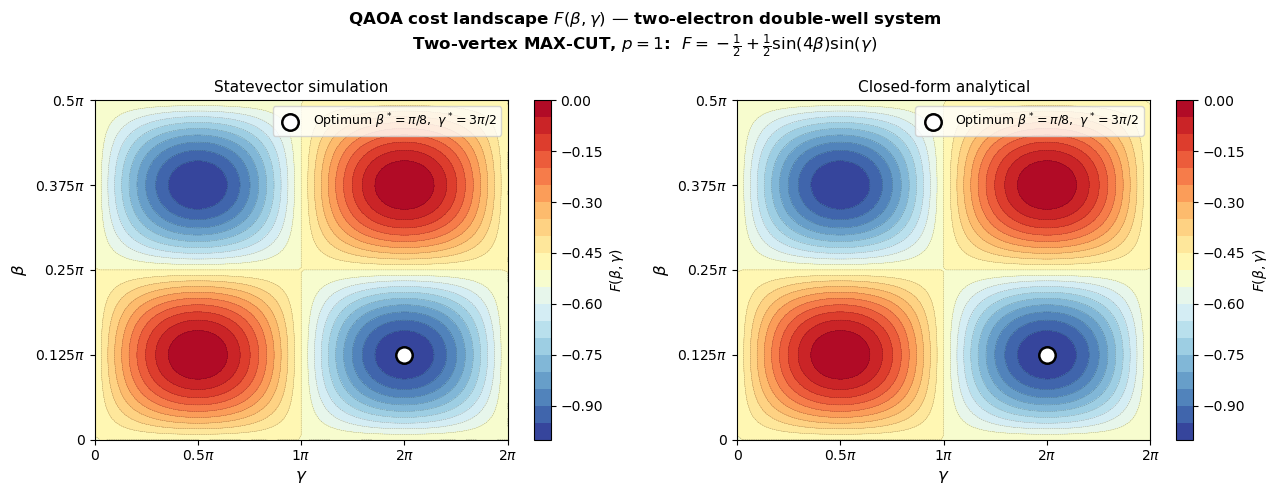

Figure saved to qaoa_landscape.png


In [5]:
beta_opt, gamma_opt = np.pi/8, 3*np.pi/2

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    r'QAOA cost landscape $F(\beta,\gamma)$ — two-electron double-well system' '\n'
    r'Two-vertex MAX-CUT, $p=1$:  $F = -\frac{1}{2} + \frac{1}{2}\sin(4\beta)\sin(\gamma)$',
    fontsize=12, fontweight='bold'
)

levels = np.linspace(-1, 0, 21)
for ax, data, title in zip(
    axes,
    [F_num, F_ana],
    ['Statevector simulation', 'Closed-form analytical']
):
    im = ax.contourf(G, B, data, levels=levels, cmap='RdYlBu_r')
    ax.contour(G, B, data, levels=levels, colors='k', linewidths=0.3, alpha=0.4)
    plt.colorbar(im, ax=ax, label=r'$F(\beta,\gamma)$')
    ax.scatter(gamma_opt, beta_opt, s=140, c='white', edgecolors='black',
               linewidths=1.8, zorder=5,
               label=r'Optimum $\beta^*=\pi/8,\ \gamma^*=3\pi/2$')
    ax.set_xlabel(r'$\gamma$', fontsize=12)
    ax.set_ylabel(r'$\beta$',  fontsize=12)
    ax.set_title(title, fontsize=11)
    ax.set_xlim(0, 2*np.pi)
    ax.set_ylim(0, np.pi/2)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(
        lambda v, _: rf'${v/np.pi:.1g}\pi$' if v > 0 else '0'))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(
        lambda v, _: rf'${v/np.pi:.3g}\pi$' if v > 0 else '0'))
    ax.xaxis.set_major_locator(MultipleLocator(np.pi/2))
    ax.yaxis.set_major_locator(MultipleLocator(np.pi/8))
    ax.legend(fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig('qaoa_landscape.png', dpi=140, bbox_inches='tight')
plt.show()
print('Figure saved to qaoa_landscape.png')


### 4.5  One-dimensional slices through the landscape

Slices along $\beta$ (with $\gamma = \gamma^* = 3\pi/2$ fixed) and along $\gamma$
(with $\beta = \beta^* = \pi/8$ fixed) confirm the sinusoidal structure and the location
of the minimum.


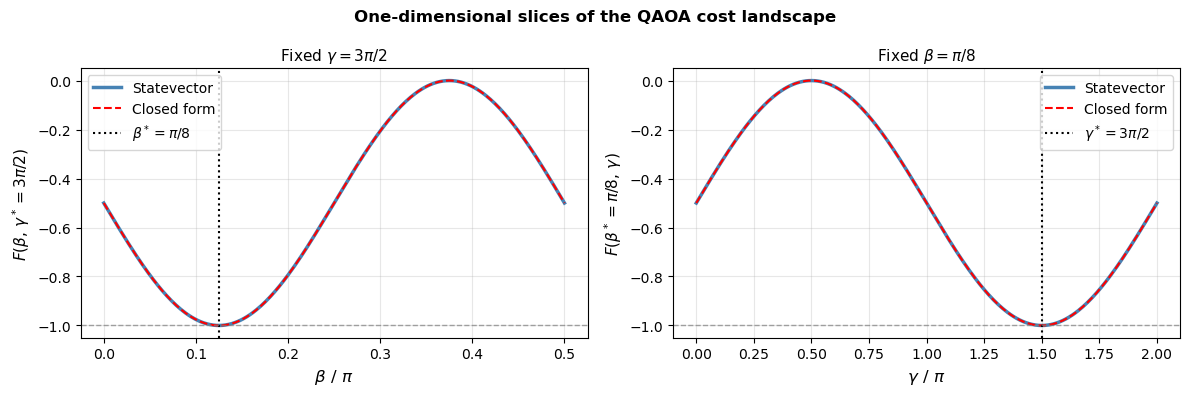

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('One-dimensional slices of the QAOA cost landscape',
             fontsize=12, fontweight='bold')

bv = np.linspace(0, np.pi/2, 300)
ax1.plot(bv/np.pi, [expected_cost(b, gamma_opt) for b in bv],
         'steelblue', lw=2.5, label='Statevector')
ax1.plot(bv/np.pi, closed_form(bv, gamma_opt),
         'r--', lw=1.5, label='Closed form')
ax1.axvline(beta_opt/np.pi, color='k', ls=':', lw=1.5,
            label=r'$\beta^* = \pi/8$')
ax1.axhline(-1, color='gray', ls='--', lw=1, alpha=0.7)
ax1.set_xlabel(r'$\beta\ /\ \pi$', fontsize=12)
ax1.set_ylabel(r'$F(\beta,\, \gamma^*{=}3\pi/2)$', fontsize=11)
ax1.set_title(r'Fixed $\gamma = 3\pi/2$', fontsize=11)
ax1.legend(fontsize=10); ax1.grid(True, alpha=0.3)

gv = np.linspace(0, 2*np.pi, 300)
ax2.plot(gv/np.pi, [expected_cost(beta_opt, g) for g in gv],
         'steelblue', lw=2.5, label='Statevector')
ax2.plot(gv/np.pi, closed_form(beta_opt, gv),
         'r--', lw=1.5, label='Closed form')
ax2.axvline(gamma_opt/np.pi, color='k', ls=':', lw=1.5,
            label=r'$\gamma^* = 3\pi/2$')
ax2.axhline(-1, color='gray', ls='--', lw=1, alpha=0.7)
ax2.set_xlabel(r'$\gamma\ /\ \pi$', fontsize=12)
ax2.set_ylabel(r'$F(\beta^*{=}\pi/8,\, \gamma)$', fontsize=11)
ax2.set_title(r'Fixed $\beta = \pi/8$', fontsize=11)
ax2.legend(fontsize=10); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('qaoa_slices.png', dpi=140, bbox_inches='tight')
plt.show()


### 4.6  Classical optimisation

We minimise $F(\beta,\gamma)$ with **COBYLA** (gradient-free, appropriate for noisy quantum
experiments) and **BFGS** (gradient-based, using finite differences), each with 20 random
restarts. Both are compared to the known analytical optimum.


In [7]:
def objective(params):
    return expected_cost(params[0], params[1])


print('COBYLA optimisation (20 random restarts) ...')
best_cobyla = None
for _ in range(20):
    b0  = np.random.uniform(0, np.pi/2)
    g0  = np.random.uniform(0, 2*np.pi)
    res = minimize(objective, [b0, g0], method='COBYLA',
                   options={'maxiter': 1000, 'rhobeg': 0.3})
    if best_cobyla is None or res.fun < best_cobyla.fun:
        best_cobyla = res

b_co, g_co = best_cobyla.x
print(f'  beta*  = {b_co:.5f}  ({b_co/np.pi:.4f} pi)')
print(f'  gamma* = {g_co:.5f}  ({g_co/np.pi:.4f} pi)')
print(f'  F*     = {best_cobyla.fun:.6f}')


print('\nBFGS optimisation (20 random restarts) ...')
best_bfgs = None
for _ in range(20):
    b0  = np.random.uniform(0, np.pi/2)
    g0  = np.random.uniform(0, 2*np.pi)
    res = minimize(objective, [b0, g0], method='BFGS',
                   options={'maxiter': 500})
    if best_bfgs is None or res.fun < best_bfgs.fun:
        best_bfgs = res

b_bf, g_bf = best_bfgs.x
print(f'  beta*  = {b_bf:.5f}  ({b_bf/np.pi:.4f} pi)')
print(f'  gamma* = {g_bf:.5f}  ({g_bf/np.pi:.4f} pi)')
print(f'  F*     = {best_bfgs.fun:.6f}')


# Analytical optimum
b_opt = np.pi/8;  g_opt = 3*np.pi/2
F_opt = closed_form(b_opt, g_opt)
print(f'\nAnalytical:  beta* = pi/8 = {b_opt:.5f},  gamma* = 3*pi/2 = {g_opt:.5f},  F* = {F_opt:.6f}')
print(f'\n|F_COBYLA - F_opt| = {abs(best_cobyla.fun - F_opt):.2e}')
print(f'|F_BFGS   - F_opt| = {abs(best_bfgs.fun   - F_opt):.2e}')


COBYLA optimisation (20 random restarts) ...
  beta*  = 1.17803  (0.3750 pi)
  gamma* = 1.57067  (0.5000 pi)
  F*     = -1.000000

BFGS optimisation (20 random restarts) ...
  beta*  = 0.39270  (0.1250 pi)
  gamma* = 4.71239  (1.5000 pi)
  F*     = -1.000000

Analytical:  beta* = pi/8 = 0.39270,  gamma* = 3*pi/2 = 4.71239,  F* = -1.000000

|F_COBYLA - F_opt| = 2.10e-08
|F_BFGS   - F_opt| = 3.33e-16


### 4.7  Optimal state and measurement probabilities

At $(\beta^*, \gamma^*) = (\pi/8,\, 3\pi/2)$ the QAOA state is the $|T_0\rangle$ triplet Bell
state, placing all weight on the two cut states.


Optimal QAOA state probabilities (beta*=pi/8, gamma*=3*pi/2):
  P(|00>) = P(|up-up>) = 0.0000
  P(|01>) = P(|up-dn>) = 0.5000  <-- MAX-CUT solution
  P(|10>) = P(|dn-up>) = 0.5000  <-- MAX-CUT solution
  P(|11>) = P(|dn-dn>) = 0.0000

Expected cost F* = -1.0000
P(finding a solution) = P(|01>) + P(|10>) = 1.0000

|<T0|psi*>|^2 = 1.000000  (1.0 means psi* = |T0>)


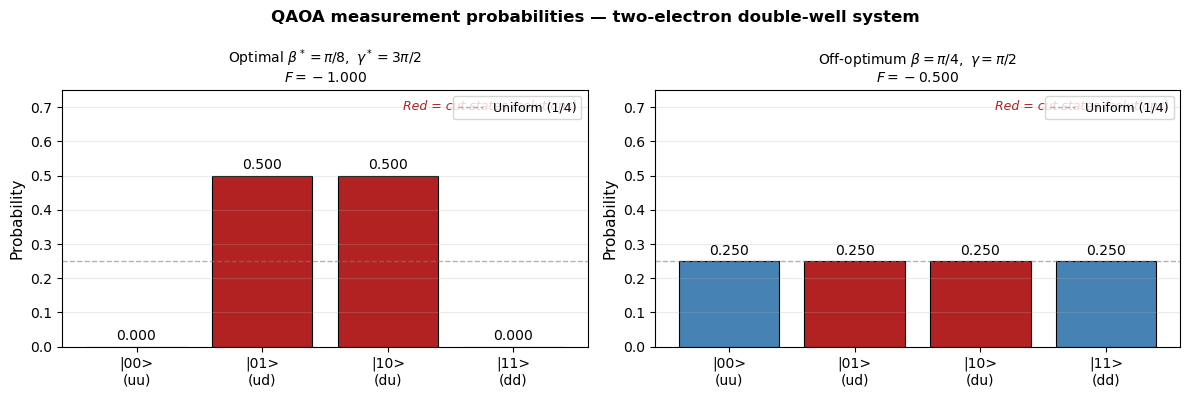

In [8]:
psi_opt = qaoa_state(b_opt, g_opt)
probs   = np.abs(psi_opt)**2

print('Optimal QAOA state probabilities (beta*=pi/8, gamma*=3*pi/2):')
for k, (lbl, sp) in enumerate(zip(['|00>','|01>','|10>','|11>'],
                                   ['|up-up>','|up-dn>','|dn-up>','|dn-dn>'])):
    sol = '  <-- MAX-CUT solution' if np.diag(H_C).real[k] < 0 else ''
    print(f'  P({lbl}) = P({sp}) = {probs[k]:.4f}{sol}')

print(f'\nExpected cost F* = {(psi_opt.conj() @ H_C @ psi_opt).real:.4f}')
print(f'P(finding a solution) = P(|01>) + P(|10>) = {probs[1]+probs[2]:.4f}')

# Verify |T0> = (|01>+|10>)/sqrt(2)
T0 = np.array([0, 1, 1, 0], dtype=complex) / np.sqrt(2)
print(f'\n|<T0|psi*>|^2 = {abs(np.vdot(T0, psi_opt))**2:.6f}  (1.0 means psi* = |T0>)')

# Bar charts: optimal vs non-optimal
colours = ['steelblue', 'firebrick', 'firebrick', 'steelblue']
bar_labels = ['|00>\n(uu)', '|01>\n(ud)', '|10>\n(du)', '|11>\n(dd)']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('QAOA measurement probabilities — two-electron double-well system',
             fontsize=12, fontweight='bold')

for ax, (b, g), subtitle in zip(
    axes,
    [(b_opt, g_opt), (np.pi/4, np.pi/2)],
    [r'Optimal $\beta^*=\pi/8,\ \gamma^*=3\pi/2$',
     r'Off-optimum $\beta=\pi/4,\ \gamma=\pi/2$']
):
    pv = np.abs(qaoa_state(b, g))**2
    ax.bar(bar_labels, pv, color=colours, edgecolor='black', linewidth=0.8)
    for k_b, p_b in enumerate(pv):
        ax.text(k_b, p_b+0.01, f'{p_b:.3f}', ha='center', va='bottom', fontsize=10)
    ax.axhline(0.25, color='gray', ls='--', lw=1, alpha=0.6, label='Uniform (1/4)')
    ax.set_ylim(0, 0.75)
    ax.set_ylabel('Probability', fontsize=11)
    ax.set_title(subtitle + f'\n$F = {expected_cost(b,g):.3f}$', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25, axis='y')
    ax.text(0.98, 0.96, 'Red = cut states (solutions)',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=9, color='firebrick', style='italic')

plt.tight_layout()
plt.savefig('qaoa_probabilities.png', dpi=140, bbox_inches='tight')
plt.show()


### 4.8  Simulated spin-measurement sampling

We simulate $N_{\rm shots}$ projective measurements from the optimal QAOA state. In a physical
double-well experiment these correspond to single-shot spin measurements via spin-to-charge
conversion and fast charge sensing.


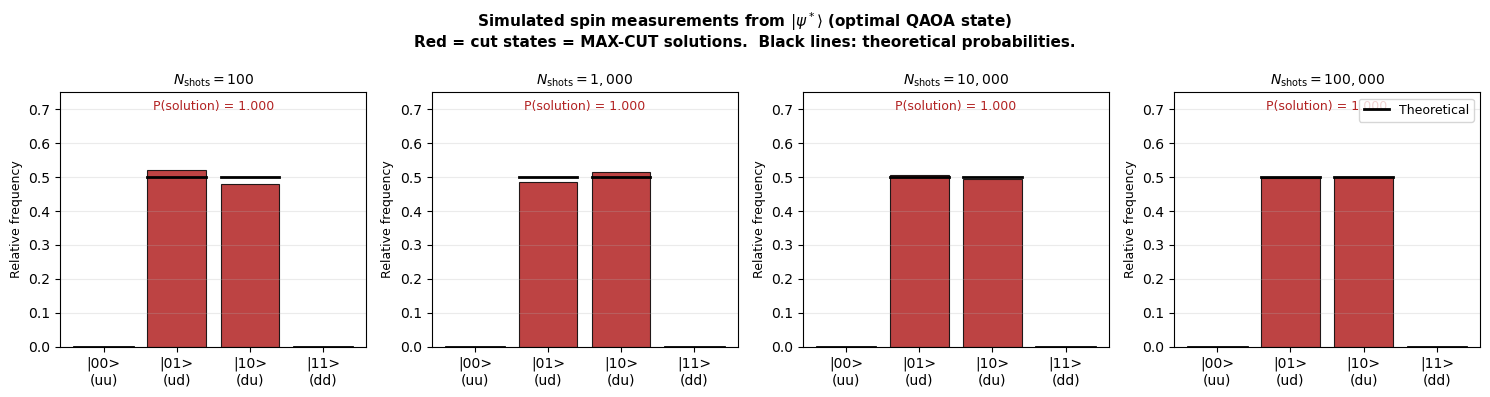

Theoretical P(solution) = 1.0000


In [9]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
fig.suptitle(
    r'Simulated spin measurements from $|\psi^*\rangle$ (optimal QAOA state)' '\n'
    'Red = cut states = MAX-CUT solutions.  Black lines: theoretical probabilities.',
    fontsize=11, fontweight='bold'
)

exact_probs = np.abs(qaoa_state(b_opt, g_opt))**2

for ax, N in zip(axes, [100, 1_000, 10_000, 100_000]):
    outcomes = np.random.choice(4, size=N, p=exact_probs)
    counts   = np.bincount(outcomes, minlength=4)
    freq     = counts / N

    ax.bar(bar_labels, freq, color=colours, edgecolor='black', linewidth=0.8, alpha=0.85)
    for k_b, (f, p_ex) in enumerate(zip(freq, exact_probs)):
        ax.plot([k_b - 0.4, k_b + 0.4], [p_ex, p_ex], 'k-', lw=2.0)

    ax.set_title(f'$N_{{\\rm shots}} = {N:,}$', fontsize=10)
    ax.set_ylim(0, 0.75)
    ax.set_ylabel('Relative frequency', fontsize=9)
    ax.grid(True, alpha=0.25, axis='y')
    frac_correct = (counts[1] + counts[2]) / N
    ax.text(0.5, 0.97, f'P(solution) = {frac_correct:.3f}',
            transform=ax.transAxes, ha='center', va='top',
            fontsize=9, color='firebrick')

axes[-1].plot([], [], 'k-', lw=2, label='Theoretical')
axes[-1].legend(fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig('qaoa_sampling.png', dpi=140, bbox_inches='tight')
plt.show()
print(f'Theoretical P(solution) = {exact_probs[1]+exact_probs[2]:.4f}')


### 4.9  General depth-$p$ QAOA

We implement the general depth-$p$ ansatz and optimise for $p = 1, 2, 3$.
For the single-edge two-vertex graph $p=1$ already achieves the global optimum $F=-1$;
the deeper circuits illustrate convergence over the expanded parameter space.


In [10]:
def qaoa_state_p(betas, gammas):
    """
    General depth-p QAOA statevector.
    |psi> = U_B(beta_p) U_C(gamma_p) ... U_B(beta_1) U_C(gamma_1) |+>^{tensor 2}
    betas, gammas : arrays of length p.
    """
    psi = np.ones(4, dtype=complex) / 2.0
    for beta, gamma in zip(betas, gammas):
        psi = cost_unitary(gamma)  @ psi
        psi = mixer_unitary(beta)  @ psi
    return psi


def objective_p(params):
    p = len(params) // 2
    psi = qaoa_state_p(params[p:], params[:p])
    return float(np.real(psi.conj() @ H_C @ psi))


results = {}
for p in [1, 2, 3]:
    best = None
    for _ in range(30):
        g0  = np.random.uniform(0, 2*np.pi, p)
        b0  = np.random.uniform(0, np.pi/2,  p)
        x0  = np.concatenate([g0, b0])
        res = minimize(objective_p, x0, method='COBYLA',
                       options={'maxiter': 3000, 'rhobeg': 0.3})
        if best is None or res.fun < best.fun:
            best = res
    psi_p  = qaoa_state_p(best.x[p:], best.x[:p])
    pr     = np.abs(psi_p)**2
    results[p] = {'F': best.fun, 'probs': pr}
    print(f'p={p}: F* = {best.fun:.6f},  r = {best.fun/F_opt:.4f},  '
          f'P(solution) = {pr[1]+pr[2]:.4f}')


p=1: F* = -1.000000,  r = 1.0000,  P(solution) = 1.0000
p=2: F* = -1.000000,  r = 1.0000,  P(solution) = 1.0000
p=3: F* = -1.000000,  r = 1.0000,  P(solution) = 1.0000


### 4.10  Performance summary: approximation ratio vs circuit depth

The **approximation ratio** $r = F^* / F_{\rm opt}$ quantifies how close the QAOA solution
is to the exact optimum ($r=1$).


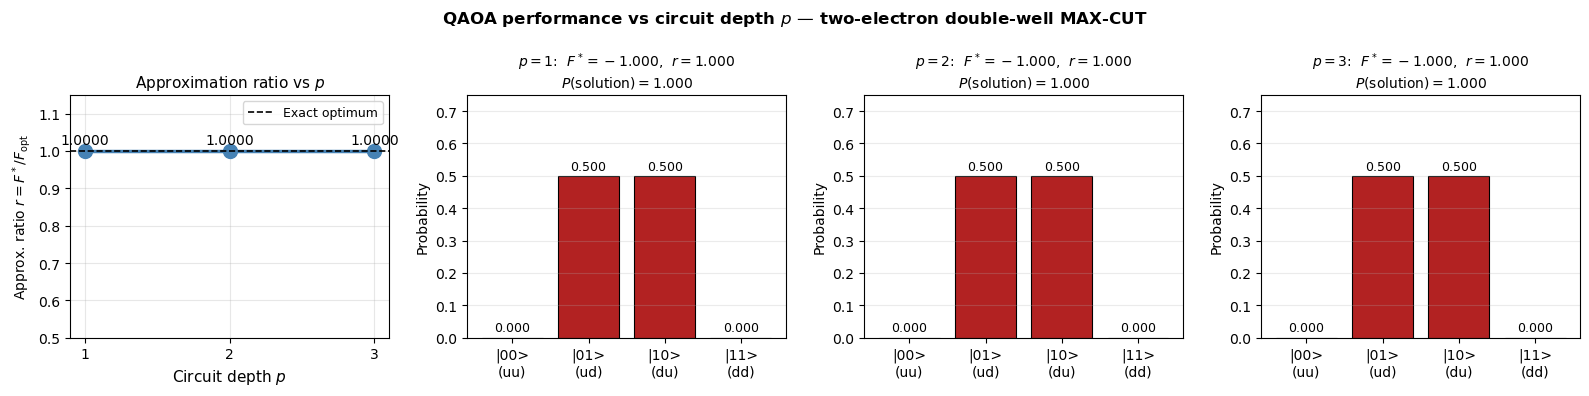

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('QAOA performance vs circuit depth $p$ — two-electron double-well MAX-CUT',
             fontsize=12, fontweight='bold')

ps     = list(results.keys())
ratios = [results[p]['F'] / F_opt for p in ps]

ax = axes[0]
ax.plot(ps, ratios, 'o-', color='steelblue', ms=10, lw=2.5)
ax.axhline(1.0, color='k', ls='--', lw=1.2, label='Exact optimum')
for p_, r_ in zip(ps, ratios):
    ax.text(p_, r_+0.01, f'{r_:.4f}', ha='center', va='bottom', fontsize=10)
ax.set_xlabel('Circuit depth $p$', fontsize=11)
ax.set_ylabel(r'Approx. ratio $r = F^*/F_{\rm opt}$', fontsize=10)
ax.set_title('Approximation ratio vs $p$', fontsize=11)
ax.set_xticks(ps); ax.set_ylim(0.5, 1.15)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

for ax, p in zip(axes[1:], [1, 2, 3]):
    pr = results[p]['probs']
    ax.bar(bar_labels, pr, color=colours, edgecolor='black', linewidth=0.8)
    for k_b, pv in enumerate(pr):
        ax.text(k_b, pv+0.01, f'{pv:.3f}', ha='center', va='bottom', fontsize=9)
    ax.set_ylim(0, 0.75)
    ax.set_ylabel('Probability', fontsize=10)
    ax.set_title(
        f'$p={p}$:  $F^*={results[p]["F"]:.3f}$,  $r={results[p]["F"]/F_opt:.3f}$\n'
        f'$P({{\\rm solution}})={pr[1]+pr[2]:.3f}$',
        fontsize=10
    )
    ax.grid(True, alpha=0.25, axis='y')

plt.tight_layout()
plt.savefig('qaoa_summary.png', dpi=140, bbox_inches='tight')
plt.show()


### 4.11  Physical interpretation and experimental roadmap

| Quantity | Value |
|:---------|:------|
| Physical system | Two spin-½ electrons, one per potential well |
| Qubit encoding | $|\!\uparrow\rangle \equiv |0\rangle$,  $|\!\downarrow\rangle \equiv |1\rangle$ |
| Problem | MAX-CUT on the two-vertex graph (single edge) |
| Cost Hamiltonian | $H_C = -\frac{1}{2}(I - Z_L Z_R)$ |
| Entangling gate | $RZZ(\gamma)$, realised by Ising exchange evolution |
| Mixing gate | $R_X(2\beta)^{\otimes 2}$, individual ESR pulses |
| Optimal parameters ($p=1$) | $\beta^* = \pi/8$, $\gamma^* = 3\pi/2$ |
| Optimal expected cost | $F^* = -1$ (global minimum) |
| Optimal state | $\frac{1}{\sqrt{2}}(|01\rangle + |10\rangle) = |T_0\rangle$ (triplet) |
| $P$(finding a solution) at $p=1$ | $1.0$ (exact) |
| Closed-form landscape | $F = -\frac{1}{2} + \frac{1}{2}\sin(4\beta)\sin(\gamma)$ |

**Physical insight.** QAOA navigates the two-electron spin system from the fully polarised
state $|\!\uparrow\uparrow\rangle$ into the equal superposition of anti-parallel configurations
$\frac{1}{\sqrt{2}}(|\!\uparrow\downarrow\rangle + |\!\downarrow\uparrow\rangle) = |T_0\rangle$.
This is the **symmetric** superposition of the two degenerate MAX-CUT solutions — not the
singlet $|S\rangle$, which would require the full Heisenberg flip-flop $XX+YY$ dynamics.

**Experimental roadmap on a semiconductor double quantum dot:**

| QAOA step | Experimental operation |
|:----------|:-----------------------|
| Initialise $|00\rangle$ | Spin polarisation by spin-selective tunnelling or optical pumping |
| Hadamard $H^{\otimes 2}$ | Two simultaneous $R_X(\pi/2)$ ESR pulses |
| Cost unitary $RZZ(\gamma)$ | CNOT–$R_Z(\gamma)$–CNOT via detuning-controlled exchange gate |
| Mixer $R_X(2\beta)^{\otimes 2}$ | Two individual microwave ESR rotations |
| Readout | Spin-to-charge conversion and fast charge sensing (one sensor per dot) |
